In [ ]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nFiles/Folders here:")
print(os.listdir())

Current Working Directory:
D:\multiomics_project\Dataset

Files/Folders here:
['.ipynb_checkpoints', 'BRCA', 'multiomics_analysis.ipynb', 'ROSMAP', 'SCZ', 'STAD', 'Untitled.ipynb']


In [ ]:
import pandas as pd
import numpy as np

# Load training data
omics1_tr = pd.read_csv("ROSMAP/1_tr.csv", header=None)
omics2_tr = pd.read_csv("ROSMAP/2_tr.csv", header=None)
omics3_tr = pd.read_csv("ROSMAP/3_tr.csv", header=None)
y_train = pd.read_csv("ROSMAP/labels_tr.csv", header=None)

# Load testing data
omics1_te = pd.read_csv("ROSMAP/1_te.csv", header=None)
omics2_te = pd.read_csv("ROSMAP/2_te.csv", header=None)
omics3_te = pd.read_csv("ROSMAP/3_te.csv", header=None)
y_test = pd.read_csv("ROSMAP/labels_te.csv", header=None)

# Flatten labels
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print("Omics 1 train shape:", omics1_tr.shape)
print("Omics 2 train shape:", omics2_tr.shape)
print("Omics 3 train shape:", omics3_tr.shape)
print("Train labels shape:", y_train.shape)

print("\nOmics 1 test shape:", omics1_te.shape)
print("Omics 2 test shape:", omics2_te.shape)
print("Omics 3 test shape:", omics3_te.shape)
print("Test labels shape:", y_test.shape)

Omics 1 train shape: (280, 200)
Omics 2 train shape: (280, 200)
Omics 3 train shape: (280, 200)
Train labels shape: (280,)

Omics 1 test shape: (71, 200)
Omics 2 test shape: (71, 200)
Omics 3 test shape: (71, 200)
Test labels shape: (71,)


In [ ]:
print("Unique train labels:", np.unique(y_train))
print("Unique test labels:", np.unique(y_test))

print("\nTrain label counts:")
print(pd.Series(y_train).value_counts())

print("\nTest label counts:")
print(pd.Series(y_test).value_counts())

Unique train labels: [0 1]
Unique test labels: [0 1]

Train label counts:
1    145
0    135
Name: count, dtype: int64

Test label counts:
1    37
0    34
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

print("Models and metrics imported successfully.")

Models and metrics imported successfully.


In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # For ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": auc,
        "Predictions": y_pred,
        "Probabilities": y_prob,
        "Trained_Model": model
    }

print("Evaluation function ready.")

Evaluation function ready.


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver='liblinear',
        C=1.0,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),

    "SVM": SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=42
    )
}

print("Models defined with parameters:")
for name, model in models.items():
    print(f"\n{name}:")
    print(model)

Models defined with parameters:

Logistic Regression:
LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

Random Forest:
RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=42)

SVM:
SVC(probability=True, random_state=42)


In [ ]:
results_omics1 = []

for name, model in models.items():
    result = evaluate_model(model, omics1_tr, y_train, omics1_te, y_test, model_name=name)
    results_omics1.append(result)

omics1_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["Predictions", "Probabilities", "Trained_Model"]}
    for r in results_omics1
])

omics1_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.690141,0.727273,0.648649,0.685714,0.771860
1,Random Forest,0.647887,0.676471,0.621622,0.647887,0.756757
2,SVM,0.647887,0.700000,0.567568,0.626866,0.753577


In [ ]:
results_omics2 = []

for name, model in models.items():
    result = evaluate_model(model, omics2_tr, y_train, omics2_te, y_test, model_name=name)
    results_omics2.append(result)

omics2_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["Predictions", "Probabilities", "Trained_Model"]}
    for r in results_omics2
])

omics2_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.563380,0.578947,0.594595,0.586667,0.641494
1,Random Forest,0.619718,0.625000,0.675676,0.649351,0.651033
2,SVM,0.591549,0.562500,0.972973,0.712871,0.614467


In [ ]:
results_omics3 = []

for name, model in models.items():
    result = evaluate_model(model, omics3_tr, y_train, omics3_te, y_test, model_name=name)
    results_omics3.append(result)

omics3_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["Predictions", "Probabilities", "Trained_Model"]}
    for r in results_omics3
])

omics3_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.760563,0.794118,0.729730,0.760563,0.853736
1,Random Forest,0.760563,0.833333,0.675676,0.746269,0.800477
2,SVM,0.746479,0.787879,0.702703,0.742857,0.796502


In [ ]:
X_train_combined = np.concatenate([omics1_tr, omics2_tr, omics3_tr], axis=1)
X_test_combined = np.concatenate([omics1_te, omics2_te, omics3_te], axis=1)

print("Combined train shape:", X_train_combined.shape)
print("Combined test shape:", X_test_combined.shape)

Combined train shape: (280, 600)
Combined test shape: (71, 600)


In [ ]:
results_combined = []

for name, model in models.items():
    result = evaluate_model(model, X_train_combined, y_train, X_test_combined, y_test, model_name=name)
    results_combined.append(result)

combined_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["Predictions", "Probabilities", "Trained_Model"]}
    for r in results_combined
])

combined_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.760563,0.763158,0.783784,0.773333,0.832273
1,Random Forest,0.718310,0.757576,0.675676,0.714286,0.798092
2,SVM,0.676056,0.769231,0.540541,0.634921,0.800477


In [ ]:
omics1_df["Input"] = "Omics 1"
omics2_df["Input"] = "Omics 2"
omics3_df["Input"] = "Omics 3"
combined_df["Input"] = "Combined"

final_results = pd.concat([omics1_df, omics2_df, omics3_df, combined_df], ignore_index=True)

final_results = final_results[["Input", "Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]]

final_results

,Input,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Omics 1,Logistic Regression,0.690141,0.727273,0.648649,0.685714,0.771860
1,Omics 1,Random Forest,0.647887,0.676471,0.621622,0.647887,0.756757
2,Omics 1,SVM,0.647887,0.700000,0.567568,0.626866,0.753577
3,Omics 2,Logistic Regression,0.563380,0.578947,0.594595,0.586667,0.641494
4,Omics 2,Random Forest,0.619718,0.625000,0.675676,0.649351,0.651033
5,Omics 2,SVM,0.591549,0.562500,0.972973,0.712871,0.614467
6,Omics 3,Logistic Regression,0.760563,0.794118,0.729730,0.760563,0.853736
7,Omics 3,Random Forest,0.760563,0.833333,0.675676,0.746269,0.800477
8,Omics 3,SVM,0.746479,0.787879,0.702703,0.742857,0.796502
9,Combined,Logistic Regression,0.760563,0.763158,0.783784,0.773333,0.832273


In [ ]:
final_results.to_csv("final_results.csv", index=False)
print("Saved as final_results.csv")

Saved as final_results.csv


In [ ]:
combined_df.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Input
0,Logistic Regression,0.760563,0.763158,0.783784,0.773333,0.832273,Combined
2,SVM,0.676056,0.769231,0.540541,0.634921,0.800477,Combined
1,Random Forest,0.718310,0.757576,0.675676,0.714286,0.798092,Combined


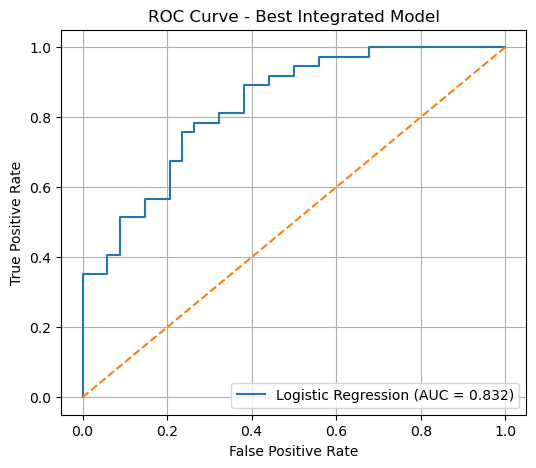

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Best combined result = Logistic Regression (index 0 in results_combined)
best_result = results_combined[0]

best_model_name = best_result["Model"]
y_prob = best_result["Probabilities"]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {best_result['ROC-AUC']:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Integrated Model")
plt.legend()
plt.grid(True)
plt.savefig("roc_curve_multiomics.png", dpi=300, bbox_inches="tight")
plt.show()

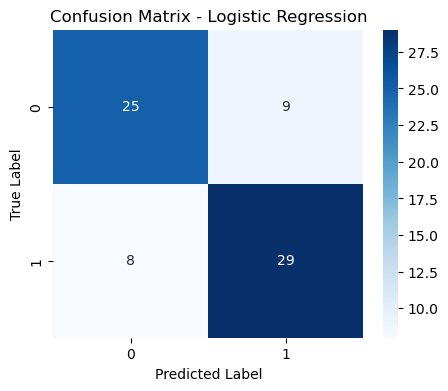

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_best = best_result["Predictions"]

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("confusion_matrix_multiomics.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train_combined, y_train)

importances = rf_model.feature_importances_
top_idx = np.argsort(importances)[-15:]

top_features = pd.DataFrame({
    "Feature_Index": top_idx,
    "Importance": importances[top_idx]
}).sort_values("Importance", ascending=False)

top_features

,Feature_Index,Importance
14,248,0.021501
13,246,0.017612
12,38,0.010230
11,195,0.008147
10,102,0.007237
9,82,0.007214
8,149,0.007040
7,487,0.006998
6,40,0.006991
5,37,0.006422


In [ ]:
top_features.to_csv("top_features.csv", index=False)
print("Saved as top_features.csv")

Saved as top_features.csv


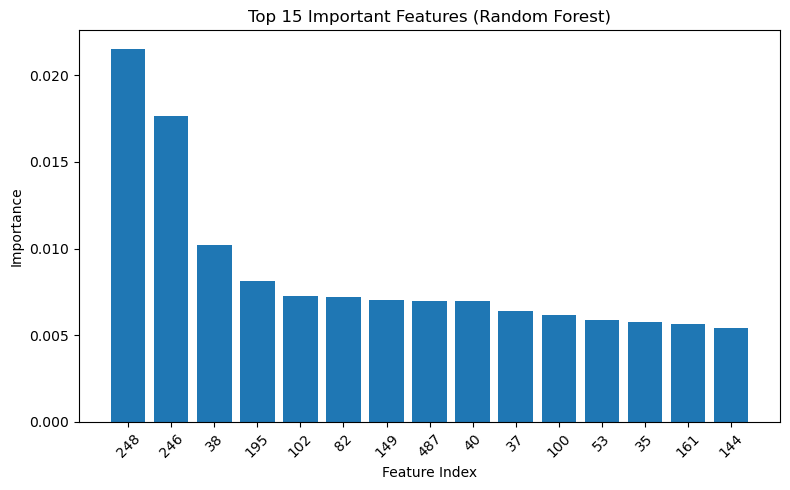

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(range(len(top_features)), top_features["Importance"])
plt.xticks(range(len(top_features)), top_features["Feature_Index"], rotation=45)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Top 15 Important Features (Random Forest)")
plt.tight_layout()
plt.savefig("feature_importance_multiomics.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_combined)
X_test_scaled = scaler.transform(X_test_combined)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (280, 600)
Scaled test shape: (71, 600)


In [ ]:
scaled_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        solver='liblinear',
        C=1.0,
        random_state=42
    ),

    "SVM": SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )
}

results_scaled = []

for name, model in scaled_models.items():
    result = evaluate_model(model, X_train_scaled, y_train, X_test_scaled, y_test, model_name=name)
    results_scaled.append(result)

scaled_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["Predictions", "Probabilities", "Trained_Model"]}
    for r in results_scaled
])

scaled_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.788732,0.775000,0.837838,0.805195,0.864070
1,SVM,0.732394,0.764706,0.702703,0.732394,0.848967
2,Random Forest,0.718310,0.757576,0.675676,0.714286,0.796502


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=100)

X_train_fs = selector.fit_transform(X_train_scaled, y_train)
X_test_fs = selector.transform(X_test_scaled)

print("Feature-selected train shape:", X_train_fs.shape)
print("Feature-selected test shape:", X_test_fs.shape)

Feature-selected train shape: (280, 100)
Feature-selected test shape: (71, 100)


In [ ]:
results_fs = []

for name, model in scaled_models.items():
    result = evaluate_model(model, X_train_fs, y_train, X_test_fs, y_test, model_name=name)
    results_fs.append(result)

fs_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["Predictions", "Probabilities", "Trained_Model"]}
    for r in results_fs
])

fs_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.718310,0.757576,0.675676,0.714286,0.810016
1,SVM,0.676056,0.694444,0.675676,0.684932,0.781399
2,Random Forest,0.732394,0.764706,0.702703,0.732394,0.759936


In [ ]:
scaled_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.788732,0.775000,0.837838,0.805195,0.864070
1,SVM,0.732394,0.764706,0.702703,0.732394,0.848967
2,Random Forest,0.718310,0.757576,0.675676,0.714286,0.796502


In [ ]:
fs_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.718310,0.757576,0.675676,0.714286,0.810016
1,SVM,0.676056,0.694444,0.675676,0.684932,0.781399
2,Random Forest,0.732394,0.764706,0.702703,0.732394,0.759936


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'C': [0.01, 0.1, 1, 5, 10, 50],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

lr = LogisticRegression(max_iter=3000, random_state=42)

grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

print("Best Logistic Regression Parameters:")
print(grid_lr.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_lr.best_score_)

Best Logistic Regression Parameters:
{'C': 50, 'penalty': 'l2', 'solver': 'lbfgs'}

Best CV ROC-AUC:
0.8794380587484035


In [ ]:
best_lr = grid_lr.best_estimator_

tuned_lr_result = evaluate_model(
    best_lr,
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    model_name="Tuned Logistic Regression"
)

tuned_lr_df = pd.DataFrame([
    {k: v for k, v in tuned_lr_result.items() if k not in ["Predictions", "Probabilities", "Trained_Model"]}
])

tuned_lr_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned Logistic Regression,0.802817,0.794872,0.837838,0.815789,0.86566


In [ ]:
summary_results = pd.DataFrame([
    {
        "Experiment": "Combined (Raw)",
        "Model": "Logistic Regression",
        "Accuracy": 0.760563,
        "Precision": 0.763158,
        "Recall": 0.783784,
        "F1-score": 0.773333,
        "ROC-AUC": 0.832273
    },
    {
        "Experiment": "Combined (Scaled)",
        "Model": "Logistic Regression",
        "Accuracy": 0.788732,
        "Precision": 0.775000,
        "Recall": 0.837838,
        "F1-score": 0.805195,
        "ROC-AUC": 0.864070
    },
    {
        "Experiment": "Combined (Scaled + Feature Selection)",
        "Model": "Logistic Regression",
        "Accuracy": 0.718310,
        "Precision": 0.757576,
        "Recall": 0.675676,
        "F1-score": 0.714286,
        "ROC-AUC": 0.810016
    },
    {
        "Experiment": "Combined (Scaled + Tuned LR)",
        "Model": "Tuned Logistic Regression",
        "Accuracy": 0.802817,
        "Precision": 0.794872,
        "Recall": 0.837838,
        "F1-score": 0.815789,
        "ROC-AUC": 0.865660
    }
])

summary_results

,Experiment,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Combined (Raw),Logistic Regression,0.760563,0.763158,0.783784,0.773333,0.832273
1,Combined (Scaled),Logistic Regression,0.788732,0.775000,0.837838,0.805195,0.864070
2,Combined (Scaled + Feature Selection),Logistic Regression,0.718310,0.757576,0.675676,0.714286,0.810016
3,Combined (Scaled + Tuned LR),Tuned Logistic Regression,0.802817,0.794872,0.837838,0.815789,0.865660


In [ ]:
summary_results.to_csv("summary_results.csv", index=False)
print("Saved as summary_results.csv")

Saved as summary_results.csv


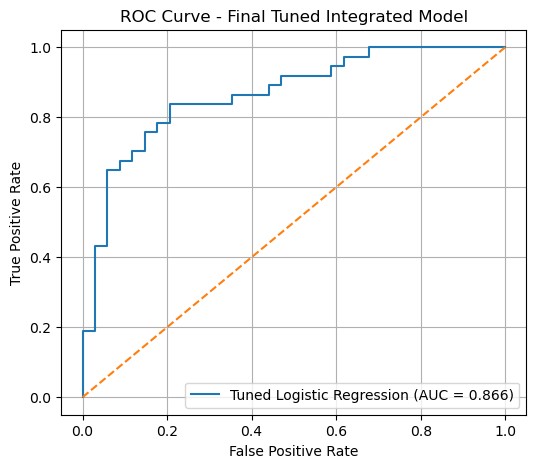

In [ ]:
# ROC for tuned logistic regression
best_final_result = tuned_lr_result

fpr, tpr, _ = roc_curve(y_test, best_final_result["Probabilities"])

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Tuned Logistic Regression (AUC = {best_final_result['ROC-AUC']:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Tuned Integrated Model")
plt.legend()
plt.grid(True)
plt.savefig("roc_curve_tuned_multiomics.png", dpi=300, bbox_inches="tight")
plt.show()

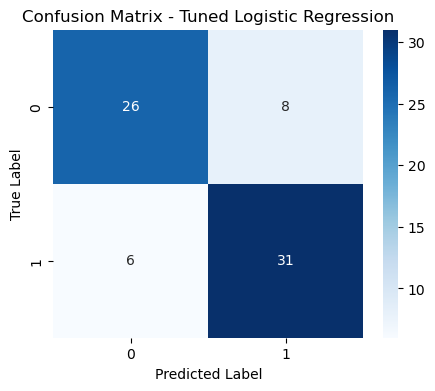

In [ ]:
y_pred_tuned = best_final_result["Predictions"]

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(5,4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("confusion_matrix_tuned_multiomics.png", dpi=300, bbox_inches="tight")
plt.show()